In [1]:
import pandas as pd
import numpy as np
from scipy.stats import kstest
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder

# About Dataset

Perusahaan Big Data ingin memprediksi apakah peserta training akan mencari pekerjaan baru atau tetap bekerja di perusahaan setelah pelatihan.

| Feature                | Deskripsi                                                        |
| ---------------------- | ---------------------------------------------------------------- |
| **enrollee_id**            | ID unik untuk setiap kandidat                                    |
| **city**                   | Kode kota kandidat                                               |
| **city_development_index** | Indeks perkembangan kota (dalam skala numerik)                   |
| **gender**                 | Jenis kelamin kandidat                                           |
| **relevant_experience**    | Pengalaman kerja yang relevan                                    |
| **enrolled_university**    | Jenis program/perkuliahan yang sedang atau pernah diikuti        |
| **education_level**        | Tingkat pendidikan terakhir kandidat                             |
| **major_discipline**       | Bidang/jurusan pendidikan kandidat                               |
| **experience**             | Total pengalaman kerja dalam tahun                               |
| **company_size**           | Jumlah karyawan di perusahaan tempat bekerja saat ini            |
| **company_type**           | Jenis perusahaan tempat bekerja saat ini                         |
| **last_new_job**           | Selisih tahun antara pekerjaan sebelumnya dan pekerjaan saat ini |
| **training_hours**         | Jumlah jam pelatihan yang telah diselesaikan                     |
| **target**                 | 0 = Tidak mencari pekerjaan baru, 1 = Mencari pekerjaan baru     |

# Mengimpor Data

## a. Membaca dataset

In [2]:
# mengimpor data csv
df = pd.read_csv("/Users/anastyarachmaindiarto/Downloads/people_analytics.csv")
# menampilkan 10 data pertama pada dataset
df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


## b. Informasi dataset

In [3]:
# memeriksa jumlah baris dan kolom pada dataset
df.shape

(19158, 14)

In [4]:
# memeriksa informasi seperti nama kolom, jumlah non-null, dan tipe data pada dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [5]:
# memeriksa kolom pada dataset
df.columns.to_list()

['enrollee_id',
 'city',
 'city_development_index',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job',
 'training_hours',
 'target']

In [6]:
# memeriksa deskripsi statistik pada data numerikal
df.describe().round(2)

,enrollee_id,city_development_index,training_hours,target
count,19158.00,19158.00,19158.00,19158.00
mean,16875.36,0.83,65.37,0.25
std,9616.29,0.12,60.06,0.43
min,1.00,0.45,1.00,0.00
25%,8554.25,0.74,23.00,0.00
50%,16982.50,0.90,47.00,0.00
75%,25169.75,0.92,88.00,0.00
max,33380.00,0.95,336.00,1.00


In [7]:
# memeriksa deskripsi pada data kategorikal
df.describe(include="object")

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,19158,14650,19158,18772,18698,16345,19093,13220,13018,18735
unique,123,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,4355,13221,13792,13817,11598,14492,3286,3083,9817,8040


# Distribusi Data

In [8]:
# Uji Distribusi Kolmogorov-Smirnov
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    # Standarisasi (Z-score)
    z_score = (df[col] - df[col].mean()) / df[col].std()

    # Drop NA jika ada
    z_score = z_score.dropna()

    # Uji KS
    stat, p = kstest(z_score, 'norm')

    print(f"Kolom: {col}")
    print(f"  Statistik uji : {stat:.4f}")
    print(f"  p-value       : {p:.6f}")

    if p > 0.05:
        print("Data berdistribusi normal\n")
    else:
        print("Data tidak berdistribusi normal\n")

Kolom: enrollee_id
  Statistik uji : 0.0576
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: city_development_index
  Statistik uji : 0.2709
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: training_hours
  Statistik uji : 0.1520
  p-value       : 0.000000
Data tidak berdistribusi normal

Kolom: target
  Statistik uji : 0.4685
  p-value       : 0.000000
Data tidak berdistribusi normal



# Data Cleaning

## a. Konsistensi Data

In [9]:
# Mengetahui isi data dan nilai unik untuk tipe data kategorikal

cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

cat_values = []

for col in cat_cols:
    cat_values.append({
        "column": col,
        "unique_values": df[col].dropna().unique().tolist(),
        "n_unique": df[col].nunique(dropna=True)
    })

cat_values_df = pd.DataFrame(cat_values)

pd.set_option("display.max_colwidth", 100)
cat_values_df

,column,unique_values,n_unique
0,city,"[city_103, city_40, city_21, city_115, city_162, city_176, city_160, city_46, city_61, city_114,...",123
1,gender,"[Male, Female, Other]",3
2,relevent_experience,"[Has relevent experience, No relevent experience]",2
3,enrolled_university,"[no_enrollment, Full time course, Part time course]",3
4,education_level,"[Graduate, Masters, High School, Phd, Primary School]",5
5,major_discipline,"[STEM, Business Degree, Arts, Humanities, No Major, Other]",6
6,experience,"[>20, 15, 5, <1, 11, 13, 7, 17, 2, 16, 1, 4, 10, 14, 18, 19, 12, 3, 6, 9, 8, 20]",22
7,company_size,"[50-99, <10, 10000+, 5000-9999, 1000-4999, 10/49, 100-500, 500-999]",8
8,company_type,"[Pvt Ltd, Funded Startup, Early Stage Startup, Other, Public Sector, NGO]",6
9,last_new_job,"[1, >4, never, 4, 3, 2]",6


In [10]:
# Mengetahui isi data kategorikal satu persatu
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

cat_values = {}

for col in cat_cols:
    cat_values[col] = df[col].dropna().unique().tolist()

cat_values

{'city': ['city_103',
  'city_40',
  'city_21',
  'city_115',
  'city_162',
  'city_176',
  'city_160',
  'city_46',
  'city_61',
  'city_114',
  'city_13',
  'city_159',
  'city_102',
  'city_67',
  'city_100',
  'city_16',
  'city_71',
  'city_104',
  'city_64',
  'city_101',
  'city_83',
  'city_105',
  'city_73',
  'city_75',
  'city_41',
  'city_11',
  'city_93',
  'city_90',
  'city_36',
  'city_20',
  'city_57',
  'city_152',
  'city_19',
  'city_65',
  'city_74',
  'city_173',
  'city_136',
  'city_98',
  'city_97',
  'city_50',
  'city_138',
  'city_82',
  'city_157',
  'city_89',
  'city_150',
  'city_70',
  'city_175',
  'city_94',
  'city_28',
  'city_59',
  'city_165',
  'city_145',
  'city_142',
  'city_26',
  'city_12',
  'city_37',
  'city_43',
  'city_116',
  'city_23',
  'city_99',
  'city_149',
  'city_10',
  'city_45',
  'city_80',
  'city_128',
  'city_158',
  'city_123',
  'city_7',
  'city_72',
  'city_106',
  'city_143',
  'city_78',
  'city_109',
  'city_24',
 

In [11]:
# Mengetahui isi data numerik satu persatu
num_cols = df.select_dtypes(include=["number"]).columns

num_values = {}

for col in num_cols:
    num_values[col] = df[col].dropna().unique().tolist()

num_values

{'enrollee_id': [8949,
  29725,
  11561,
  33241,
  666,
  21651,
  28806,
  402,
  27107,
  699,
  29452,
  23853,
  25619,
  5826,
  8722,
  6588,
  4167,
  5764,
  2156,
  11399,
  31972,
  19061,
  6491,
  7041,
  22767,
  14505,
  17139,
  28476,
  21538,
  10408,
  14928,
  22293,
  4324,
  26966,
  26494,
  4866,
  12726,
  10164,
  8612,
  24659,
  2547,
  13854,
  31654,
  13643,
  5590,
  22452,
  9006,
  25987,
  4476,
  25103,
  5568,
  2195,
  30533,
  28512,
  1023,
  12253,
  25296,
  13238,
  13478,
  18578,
  29975,
  26516,
  24690,
  8433,
  9572,
  5878,
  25695,
  9645,
  12730,
  4830,
  20970,
  17271,
  12731,
  10908,
  29117,
  3686,
  22683,
  22134,
  31765,
  31449,
  5987,
  21762,
  22070,
  25413,
  5902,
  28403,
  30937,
  28751,
  29290,
  32401,
  19128,
  29036,
  16869,
  10497,
  18099,
  12081,
  7364,
  11184,
  7016,
  8695,
  6172,
  14672,
  18257,
  24493,
  1180,
  28627,
  8168,
  10473,
  25349,
  5220,
  4789,
  11338,
  27963,
  8571,
 

In [12]:
# Membuat ringkasan untuk setiap variabel
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "unique_values_sample": [
        df[col].dropna().unique()[:100] for col in df.columns
    ]
})

summary

,dtype,n_unique,unique_values_sample
enrollee_id,int64,19158,"[8949, 29725, 11561, 33241, 666, 21651, 28806, 402, 27107, 699, 29452, 23853, 25619, 5826, 8722,..."
city,object,123,"[city_103, city_40, city_21, city_115, city_162, city_176, city_160, city_46, city_61, city_114,..."
city_development_index,float64,93,"[0.92, 0.7759999999999999, 0.624, 0.789, 0.767, 0.764, 0.762, 0.913, 0.926, 0.8270000000000001, ..."
gender,object,3,"[Male, Female, Other]"
relevent_experience,object,2,"[Has relevent experience, No relevent experience]"
enrolled_university,object,3,"[no_enrollment, Full time course, Part time course]"
education_level,object,5,"[Graduate, Masters, High School, Phd, Primary School]"
major_discipline,object,6,"[STEM, Business Degree, Arts, Humanities, No Major, Other]"
experience,object,22,"[>20, 15, 5, <1, 11, 13, 7, 17, 2, 16, 1, 4, 10, 14, 18, 19, 12, 3, 6, 9, 8, 20]"
company_size,object,8,"[50-99, <10, 10000+, 5000-9999, 1000-4999, 10/49, 100-500, 500-999]"


Agar dapat sesuai dengan tujuan analisis, kolom **experience** akan diubah tipe datanya menjadi numerik.

## b. Data Issue

### 1. Missing values

In [13]:
# Mengetahui jumlah missing value pada setiap kolom
missing_df = pd.DataFrame({
    "Jumlah Missing Value": df.isna().sum(),
    "Persentase Missing Value": (df.isna().mean() * 100).round(2).astype(str) + "%"
})

# Menambahkan header untuk nama kolom
missing_df.index.name = "Nama Kolom"

missing_df

,Jumlah Missing Value,Persentase Missing Value
Nama Kolom,,
enrollee_id,0,0.0%
city,0,0.0%
city_development_index,0,0.0%
gender,4508,23.53%
relevent_experience,0,0.0%
enrolled_university,386,2.01%
education_level,460,2.4%
major_discipline,2813,14.68%
experience,65,0.34%


**Terdapat beberapa kolom yang memiliki missing values, di antaranya sebagai berikut.**
1. **gender** memiliki 4508 missing values dengan 23,53% nilai yang hilang.
2. **enrolled_university** memiliki 386 missing values dengan 2,01% nilai yang hilang.
3. **education_level** memiliki 460 missing values dengan 2,4% nilai yang hilang.
4. **major_dicipline** memiliki 2813 missing values dengan 14,68% nilai yang hilang.
5. **experience** memiliki 65 missing values dengan 0,34% nilai yang hilang.
6. **company_size** memiliki 5938 missing values dengan 30,99% nilai yang hilang.
7. **company_type** memiliki 6140 missing values dengan 32,05% nilai yang hilang.
6. **last_new_job** memiliki 423 missing values dengan 2,21% nilai yang hilang.

### 2. Duplikasi data

In [14]:
# Memeriksa duplikasi data 
print(df.duplicated().sum())

0


Tidak ditemukan adanya duplikasi pada data.

### 3. Outlier

In [15]:
# Memeriksa outlier
num_cols = df.select_dtypes(include=["number"]).columns

# Hitung Q1, Q3, IQR
q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Identifikasi outlier
outlier_mask = (df[num_cols] < lower) | (df[num_cols] > upper)
outlier_values = df[outlier_mask] # Untuk melihat nilai outlier
jumlah_outlier = outlier_mask.sum(axis=0)

# Total jumlah data (baris)
total_data = len(df)

# Hitung persentase outlier per kolom
persentase_outlier = (jumlah_outlier / total_data * 100).round(2).astype(str) + "%"

# Gabungkan jumlah & persentase ke dalam DataFrame
outlier_summary = pd.DataFrame({
    "Jumlah Outlier": jumlah_outlier,
    "Persentase Outlier (%)": persentase_outlier
})

outlier_summary

,Jumlah Outlier,Persentase Outlier (%)
Nama Kolom,,
enrollee_id,0,0.0%
city_development_index,17,0.09%
training_hours,984,5.14%
target,4777,24.93%


Berdasarkan hasil deteksi outlier, variabel numerik seperti **city_development_index** dan **training_hours** menunjukkan keberadaan outlier dengan persentase yang relatif kecil, yaitu masing-masing sebesar **0,09%** dan **5,14%**. Sementara itu, deteksi pada variabel **target (24,93%)** muncul karena karakteristik distribusi data biner, sehingga tidak dapat dikategorikan sebagai outlier dalam konteks analisis klasifikasi.

Dalam konteks data HR dan pelatihan, nilai ekstrem pada **training_hours** kemungkinan besar bukan merupakan kesalahan pencatatan, melainkan mencerminkan variasi nyata dalam tingkat partisipasi atau intensitas pelatihan kandidat. Demikian pula, variasi pada **city_development_index** merepresentasikan perbedaan tingkat perkembangan antar kota, yang secara alami dapat menghasilkan nilai ekstrem.

Oleh karena itu, **outlier dipertahankan** karena mencerminkan variasi nyata dalam karakteristik kandidat dan lingkungan kerja. Tidak dilakukan penghapusan data agar informasi penting tetap terjaga.

# Handling issue

In [16]:
df_handling = df.copy()

In [17]:
# if 'experience_num' in df_handling.columns:
     # df_handling.drop(['enrollee_id', 'experience'], axis=1, inplace=True)

In [18]:
# untuk mengkonversi kolom 'experience' ke numerik
def convert_experience(x):
    if pd.isna(x):            # jika nilainya NaN, biarkan tetap NaN
        return np.nan         
    elif x == '>20':          # jika nilai '>20', diasumsikan sebagai 21 tahun
        return 21             # karena menunjukkan lebih dari 20 tahun pengalaman
    elif x == '<1':           # jika nilai '<1', diasumsikan sebagai 0 tahun
        return 0              # karena kurang dari 1 tahun pengalaman
    else:
        try:
            return int(x)     # jika berupa angka dalam bentuk string, konversi menjadi integer
        except:
            return np.nan     # jika terjadi error dalam konversi, kembalikan sebagai NaN agar tidak merusak analisis

In [19]:
# mengubah konsistensi data pada kolom 'company_size'
df_handling['company_size'] = df_handling['company_size'].replace(to_replace='10/49', value='10-49')

# memperbaiki typo nama kolom
df_handling.rename(columns={'relevent_experience': 'relevant_experience'}, inplace=True)

# memperbaiki typo isi kategori
df_handling['relevant_experience'] = df_handling['relevant_experience'].replace({
    'Has relevent experience': 'Has relevant experience',
    'No relevent experience': 'No relevant experience'
})

# ubah kolom experience dari string ke numerik
df_handling['experience'] = df_handling['experience'].apply(convert_experience)

# isi massing value di kolom experience dengan median
df_handling['experience'] = df_handling['experience'].fillna(df_handling['experience'].median())

# isi missing value pada kolom kategorikal dengan "Unknown"
text_cols = ['gender', 'relevant_experience', 'enrolled_university', 
             'education_level', 'major_discipline', 'company_size', 
             'company_type', 'last_new_job']

for col in text_cols:
    df_handling[col] = df_handling[col].fillna('Unknown')

In [20]:
df_handling.isna().sum()

Nama Kolom
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevant_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [21]:
# Membuat ringkasan untuk setiap variabel setelah handling issue
summary = pd.DataFrame({
    "dtype": df_handling.dtypes.astype(str),
    "n_unique": df_handling.nunique(),
    "unique_values_sample": [
        df_handling[col].dropna().unique()[:100] for col in df_handling.columns
    ]
})

summary

,dtype,n_unique,unique_values_sample
Nama Kolom,,,
enrollee_id,int64,19158,"[8949, 29725, 11561, 33241, 666, 21651, 28806, 402, 27107, 699, 29452, 23853, 25619, 5826, 8722,..."
city,object,123,"[city_103, city_40, city_21, city_115, city_162, city_176, city_160, city_46, city_61, city_114,..."
city_development_index,float64,93,"[0.92, 0.7759999999999999, 0.624, 0.789, 0.767, 0.764, 0.762, 0.913, 0.926, 0.8270000000000001, ..."
gender,object,4,"[Male, Unknown, Female, Other]"
relevant_experience,object,2,"[Has relevant experience, No relevant experience]"
enrolled_university,object,4,"[no_enrollment, Full time course, Unknown, Part time course]"
education_level,object,6,"[Graduate, Masters, High School, Unknown, Phd, Primary School]"
major_discipline,object,7,"[STEM, Business Degree, Unknown, Arts, Humanities, No Major, Other]"
experience,float64,22,"[21.0, 15.0, 5.0, 0.0, 11.0, 13.0, 7.0, 17.0, 2.0, 16.0, 1.0, 4.0, 10.0, 14.0, 18.0, 19.0, 12.0,..."


Mengubah inkonsistensi penulisan dari isi baris pada kolom **`company_size`**, sebelumnya adalah `10/49` kemudian diperbaiki menjadi **10-49**.

Ditemukan inkonsistensi penulisan pada kolom **`relevent_experience`**, sehingga dilakukan perbaikan nama kolom menjadi **`relevant_experience`** untuk menjaga konsistensi struktur dataset. Kesalahan ejaan juga ditemukan pada isi kategori, yaitu:
* `"Has relevent experience"` diperbaiki menjadi **"Has relevant experience"**
* `"No relevent experience"` diperbaiki menjadi **"No relevant experience"**
Perbaikan ini dilakukan untuk memastikan setiap kategori merepresentasikan nilai yang seragam.

Dilakukan penanganan pada kolom **`experience`** yang memiliki format data tidak konsisten (campuran string numerik, simbol khusus seperti `'>20'` dan `'<1'`, serta nilai kosong). Untuk menjaga konsistensi tipe data:

* `'>20'` dikonversi menjadi **21 tahun**
* `'<1'` dikonversi menjadi **0 tahun**
* Nilai numerik dalam bentuk string dikonversi menjadi integer
* Nilai tidak valid dikembalikan sebagai NaN

Setelah konversi, **nilai kosong pada kolom `experience` diisi menggunakan median**. Pemilihan median dilakukan karena lebih robust terhadap outlier dan lebih representatif untuk data pengalaman kerja yang cenderung tidak terdistribusi normal.

Sementara itu, **nilai kosong pada kolom kategorikal** seperti:

* `gender`
* `relevant_experience`
* `enrolled_university`
* `education_level`
* `major_discipline`
* `company_size`
* `company_type`
* `last_new_job`

diisi dengan kategori baru yaitu **"Unknown"**.

Pendekatan ini dipilih karena untuk menghindari penghapusan baris yang dapat mengurangi jumlah data secara signifikan dan mempertahankan informasi bahwa data memang tidak tersedia. Dengan langkah-langkah tersebut, dataset telah memiliki tipe data yang konsisten (numerik dan kategorikal terdefinisi jelas), tidak mengandung missing value yang belum ditangani, dan siap untuk dianalisis lebih lanjut.

## Encoding

In [22]:
df_encoded = df_handling.copy()

In [23]:
# Encoding kolom kategorikal menjadi numerik
encoding = df_encoded.select_dtypes(include=["object"]).columns

label_encoders = {}

for col in encoding:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Memilih fitur numerik + hasil encoding
non = df_encoded.select_dtypes(include=["number"]).columns

df_final = df_encoded[non.to_list()]

# Melihat hasil dataset akhir
df_final.head()

# Menampilkan mapping label agar tahu arti setiap angka
for col, le in label_encoders.items():
    print(f"\nKolom: {col}")
    label_mapping = pd.DataFrame({
        'Label': le.transform(le.classes_),
        'Kategori_Asli': le.classes_
    })
    print(label_mapping)


Kolom: city
     Label Kategori_Asli
0        0        city_1
1        1       city_10
2        2      city_100
3        3      city_101
4        4      city_102
..     ...           ...
118    118       city_93
119    119       city_94
120    120       city_97
121    121       city_98
122    122       city_99

[123 rows x 2 columns]

Kolom: gender
   Label Kategori_Asli
0      0        Female
1      1          Male
2      2         Other
3      3       Unknown

Kolom: relevant_experience
   Label            Kategori_Asli
0      0  Has relevant experience
1      1   No relevant experience

Kolom: enrolled_university
   Label     Kategori_Asli
0      0  Full time course
1      1  Part time course
2      2           Unknown
3      3     no_enrollment

Kolom: education_level
   Label   Kategori_Asli
0      0        Graduate
1      1     High School
2      2         Masters
3      3             Phd
4      4  Primary School
5      5         Unknown

Kolom: major_discipline
   Label    Kate

# Heatmap

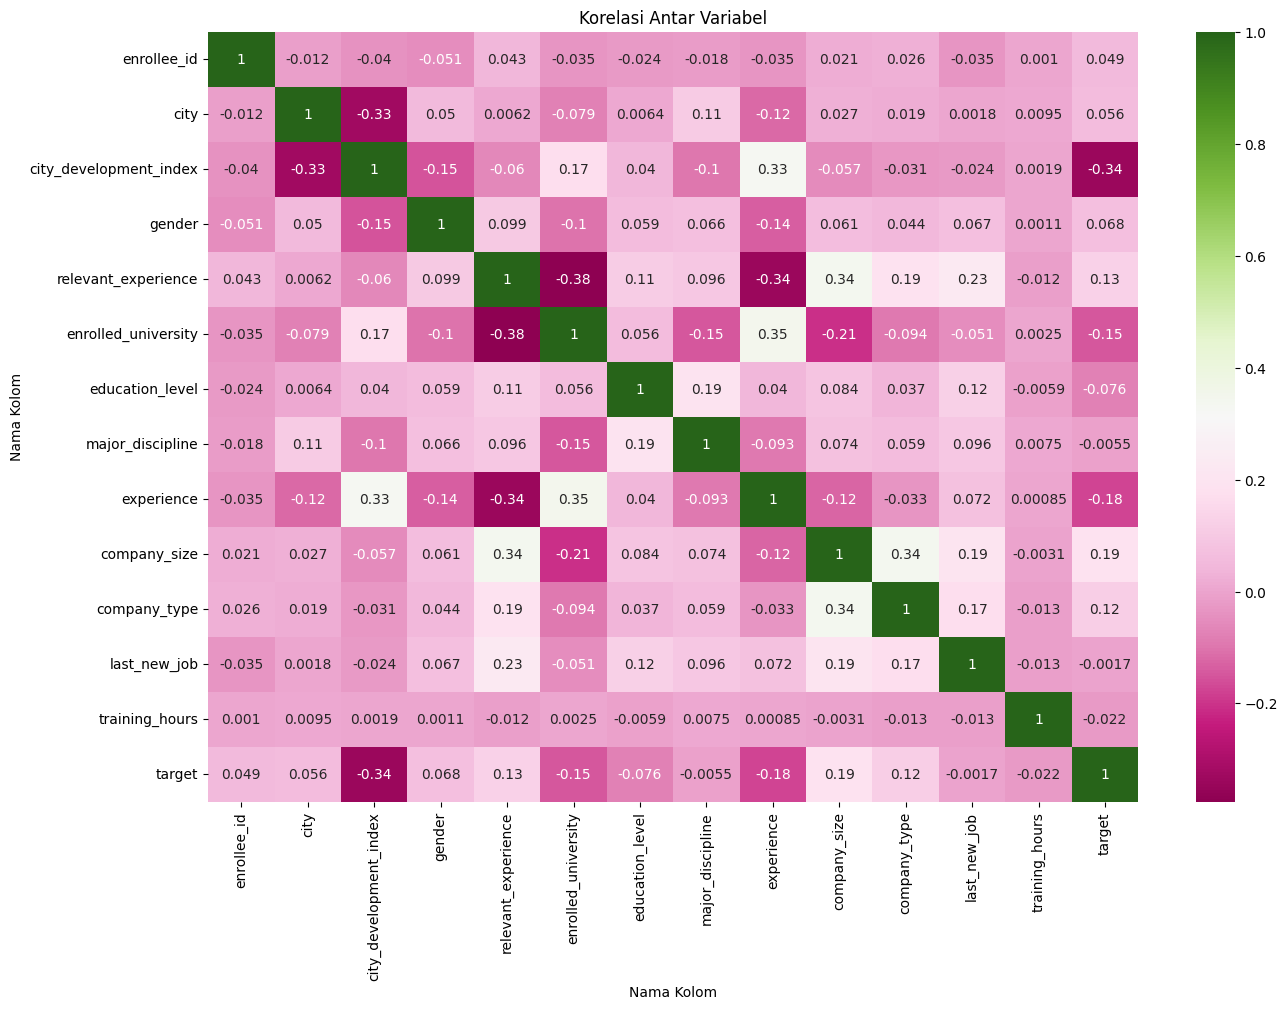

In [24]:
# Menghitung matriks korelasi
hm_data = df_encoded.corr(numeric_only=True)

# Memvisualisasikan heatmap untuk melihat korelasi antar variable
plt.figure(figsize=(15,10))
sns.heatmap(hm_data, annot=True,cmap="PiYG")
plt.title("Korelasi Antar Variabel")
plt.show()

# Eksplorasi Metrik

## Employee Turnover

In [25]:
df_final['target'].value_counts(normalize=True)*100

target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64

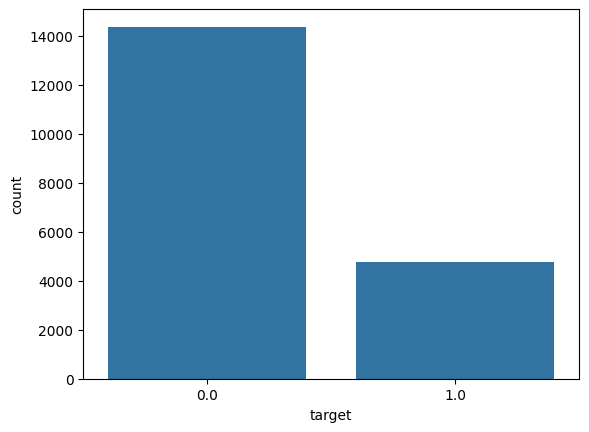

In [26]:
sns.countplot(x='target', data=df_final)
plt.show()

sebanyak 24,9% mencari pekerjaan baru, ada risiko turnover.

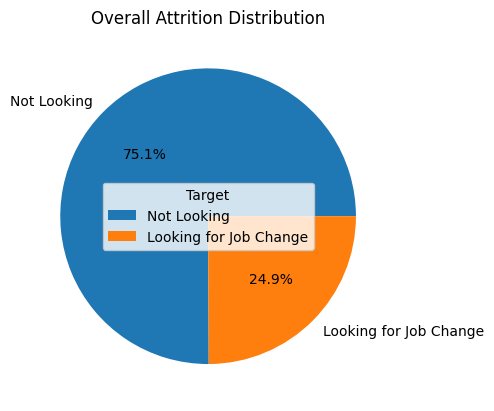

Attrition Rate: 0.24934753105752167


In [30]:
# Attrition Rate
plt.figure()

df_handling['target'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Not Looking', 'Looking for Job Change']
)

plt.title('Overall Attrition Distribution')
plt.legend(title='Target')
plt.ylabel('')
plt.show()

print("Attrition Rate:", df_handling['target'].mean())

<Figure size 640x480 with 0 Axes>

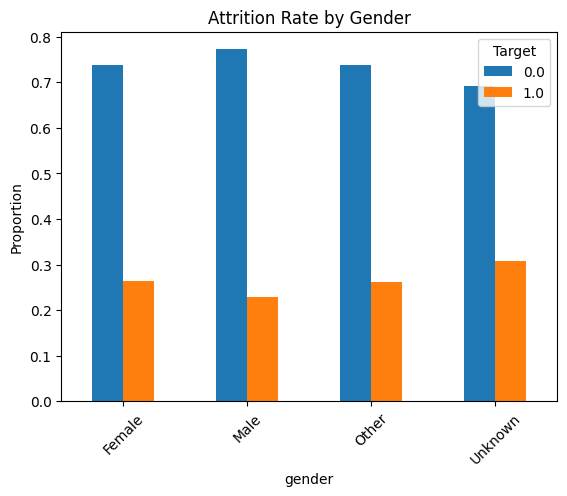

In [31]:
# gender
plt.figure()

gender_attrition = pd.crosstab(
    df_handling['gender'],
    df_handling['target'],
    normalize='index'
)

gender_attrition.plot(kind='bar')
plt.title('Attrition Rate by Gender')
plt.ylabel('Proportion')
plt.legend(title='Target')
plt.xticks(rotation=45)
plt.show()

/var/folders/2s/pw79l2x91x76nzp1v2dfvj8r0000gn/T/ipykernel_58504/1561212614.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  career_attrition = df_handling.groupby('career_stage')['target'].mean()


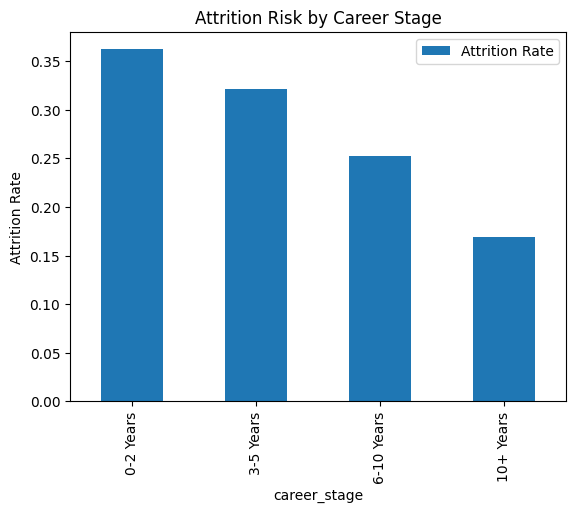

In [33]:
# experience
bins = [0, 2, 5, 10, df_handling['experience'].max()]
labels = ['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years']

df_handling['career_stage'] = pd.cut(
    df_handling['experience'],
    bins=bins,
    labels=labels
)

plt.figure()

career_attrition = df_handling.groupby('career_stage')['target'].mean()

career_attrition.plot(kind='bar')
plt.title('Attrition Risk by Career Stage')
plt.ylabel('Attrition Rate')
plt.legend(['Attrition Rate'])
plt.show()

/var/folders/2s/pw79l2x91x76nzp1v2dfvj8r0000gn/T/ipykernel_58504/3933104201.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  training_attrition = df_handling.groupby('training_intensity')['target'].mean()


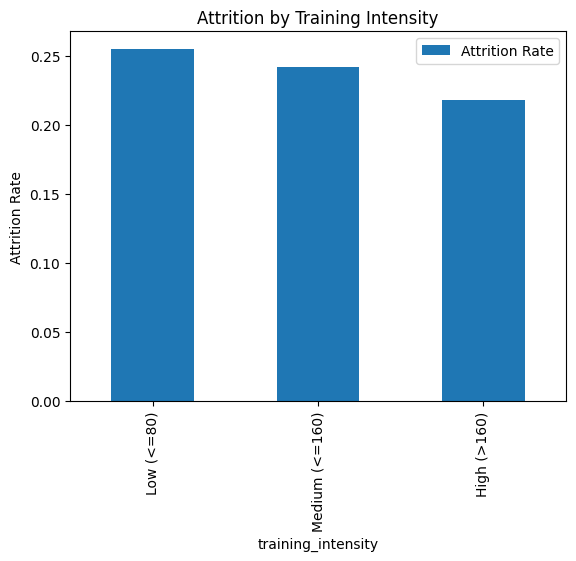

In [34]:
# training hours
bins = [0, 80, 160, df_handling['training_hours'].max()]
labels = ['Low (<=80)', 'Medium (<=160)', 'High (>160)']

df_handling['training_intensity'] = pd.cut(
    df_handling['training_hours'],
    bins=bins,
    labels=labels
)

plt.figure()

training_attrition = df_handling.groupby('training_intensity')['target'].mean()

training_attrition.plot(kind='bar')
plt.title('Attrition by Training Intensity')
plt.ylabel('Attrition Rate')
plt.legend(['Attrition Rate'])
plt.show()

/var/folders/2s/pw79l2x91x76nzp1v2dfvj8r0000gn/T/ipykernel_58504/2834058322.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_attrition = df_handling.groupby('region_development_level')['target'].mean()


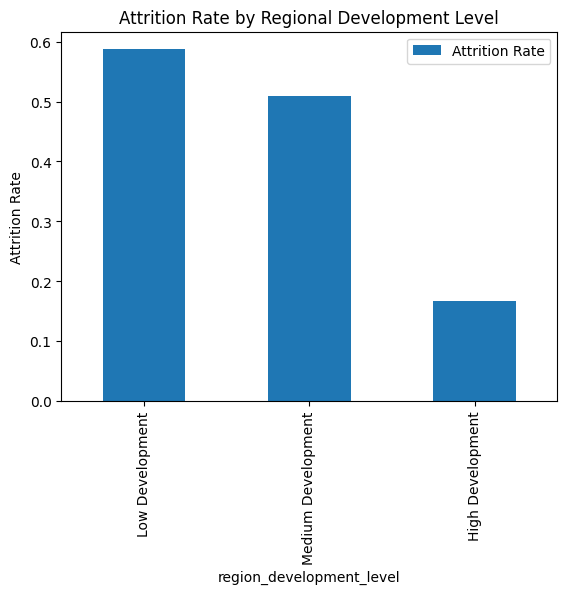

In [36]:
bins = [0, 0.5, 0.7, 1]
labels = ['Low Development', 'Medium Development', 'High Development']

df_handling['region_development_level'] = pd.cut(
    df_handling['city_development_index'],
    bins=bins,
    labels=labels
)

plt.figure()

region_attrition = df_handling.groupby('region_development_level')['target'].mean()

region_attrition.plot(kind='bar')
plt.title('Attrition Rate by Regional Development Level')
plt.ylabel('Attrition Rate')
plt.legend(['Attrition Rate'])
plt.show()